<br>
<a href="https://github.com/aperture-systems-lab">
    <img src="assets/banner_semillero.png" width="955" style="margin: 0px 0px 12px;"/>
</a>
<h1 style="line-height: 1.4;"><font color="#29c4d9"><b>Cómo funcionan las redes neuronales</b></font></h1>
<h2><b>Notebook 2: </b>Clasificación</h2>

In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

import utils

torch.manual_seed(42)

----

<br>

## **Parte 0:** Nuestro objetivo

<div style="float: right; width: 36%; min-width: 170px; max-width: 300px; margin: 4px 0px 12px 30px;">
  <img src="assets/titanic.png" width="100%" alt="Hundimiento del Titanic"
       style="display: block; transform: rotate(-1.5deg);
              filter: drop-shadow(0px 12px 20px rgba(41, 196, 217, 0.35));"/>
</div>

Todos vimos *Titanic*, ¿sí o qué? Por si acaso, un recorderis pa los de peor memoria: 

La taquillera película de James Cameron (2.200 millones de dólares de recaudó) cuenta la historia de Jack Dawson (Leonardo Dicaprio), un joven pobre que viaja en tercera clase, y Rose DeWitt Bukater, una joven de primera clase comprometida con un millonario. Que terminan en una epopeya romantica en un viaje transatlantico.

Ambos el 15 de abril de 1912, durante su viaje inaugural, el RMS Titanic (considerado "insumergible") se hundió tras chocar con un iceberg. No había botes salvavidas para todos, y de las 2224 personas a bordo murieron 1502.

Al analizar los datos del evento vimos que el pobre muere más fácil que el rico y que se le daba prioridad a las mujeres y niños. Esto sugiere que dado un choque existen gente más probable en morir que otra, en el final casi estaba escrito: Rose era mujer y de primera clase mientras que Jack era hombre y de tercera clase.

El objetivo de este notebook es construir un modelo de **redes neuronales** que prediga **si un pasajero sobrevivió o no** a partir de sus datos.

<div style="clear: both;"></div>

----

<br>

## **Parte 1:** Los datos

Usaremos el registro de pasajeros del Titanic, el reto clásico de [Kaggle](https://www.kaggle.com/c/titanic), repartido en `train.csv` y `test.csv`.

De cada pasajero tenemos la siguiente información:

| Columna | Significado |
|---|---|
| `Pclass` | clase del tiquete (1ª, 2ª o 3ª) |
| `Sex` | sexo |
| `Age` | edad en años |
| `SibSp` | hermanos o pareja a bordo |
| `Parch` | padres o hijos a bordo |
| `Ticket`, `Fare`, `Cabin` | tiquete, tarifa pagada y camarote |
| `Embarked` | puerto de embarque (C, Q o S) |
| `Survived` | $1$ si sobrevivió, $0$ si no |

A diferencia del notebook anterior, acá la salida no es un número cualquiera sino una decisión entre dos opciones.

Por lo que queremos un modelo de la forma:

$$
F: x \rightarrow y \in \{0, 1\}
$$

que a partir de la información de un pasajero estime qué tan probable era que sobreviviera. 

A este tipo de problema se le llama **clasificación**. Mientras que el problema del notebook anterior se la llamaba **regresión**.

In [2]:
train_df = pd.read_csv("data/titanic/train.csv")
test_df = pd.read_csv("data/titanic/test.csv")

pasajeros_raw = pd.concat([train_df, test_df], ignore_index=True)

print("dimensiones:", pasajeros_raw.shape)
pasajeros_raw.head()

dimensiones: (1309, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


----

<br>

## **Parte 2:** Preparación de los datos

In [3]:
def preprocess(df):
    df = df.copy()

    # Quita signos de puntuación del inicio y final de cada palabra del nombre
    def normalize_name(x):
        return " ".join([v.strip(",()[].\"'") for v in x.split(" ")])

    # Devuelve la última parte del ticket (normalmente el número)
    def ticket_number(x):
        return x.split(" ")[-1]

    # Devuelve el prefijo del ticket unido con "_", o "NONE" si no tiene
    def ticket_item(x):
        items = x.split(" ")
        if len(items) == 1:
            return "NONE"
        return "_".join(items[0:-1])

    # Aplica la limpieza
    df["Name"] = df["Name"].apply(normalize_name)
    df["Ticket_number"] = df["Ticket"].apply(ticket_number)
    df["Ticket_item"] = df["Ticket"].apply(ticket_item)
    return df


preprocessed_df = preprocess(train_df)

# Selecionar las variables de entrada
input_features = list(preprocessed_df.columns)
input_features.remove("Ticket")
input_features.remove("PassengerId")
input_features.remove("Survived")
input_features.remove("Name")

print(f"Input features: {input_features}")
preprocessed_df.head(5)

Input features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin', 'Embarked', 'Ticket_number', 'Ticket_item']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Ticket_number,Ticket_item
0,1,0,3,Braund Mr Owen Harris,male,22.0,1,0,A/5 21171,7.2500,NaN,S,21171,A/5
1,2,1,1,Cumings Mrs John Bradley Florence Briggs Thayer,female,38.0,1,0,PC 17599,71.2833,C85,C,17599,PC
2,3,1,3,Heikkinen Miss Laina,female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,3101282,STON/O2.
3,4,1,1,Futrelle Mrs Jacques Heath Lily May Peel,female,35.0,1,0,113803,53.1000,C123,S,113803,NONE
4,5,0,3,Allen Mr William Henry,male,35.0,0,0,373450,8.0500,NaN,S,373450,NONE


In [4]:
preprocessed_train_df, preprocessed_serving_df = train_test_split(
    preprocessed_df,
    test_size=0.2,
    random_state=42
)

print(f"{len(preprocessed_train_df)} ejemplos de entrenamiento, {len(preprocessed_serving_df)} ejemplos de prueba.")

712 ejemplos de entrenamiento, 179 ejemplos de prueba.


In [5]:
def to_tensors(df, input_features):
    df = df[input_features + ["Survived"]].copy()

    # Rellena valores faltantes
    df = df.fillna({
        "Age": df["Age"].median(), 
        "Fare": df["Fare"].median(),
        "Embarked": "S", 
        "Cabin": "NONE"})

    # Convierte cada columna de texto en números enteros
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = pd.factorize(df[col])[0]

    X = torch.tensor(df[input_features].values, dtype=torch.float32)
    y = torch.tensor(df["Survived"].values, dtype=torch.float32).unsqueeze(1)

    return X, y


X_train, y_train = to_tensors(preprocessed_train_df, input_features)
X_val, y_val = to_tensors(preprocessed_serving_df, input_features)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: torch.Size([712, 10])
y_train shape: torch.Size([712, 1])


----

<br>

## **Parte 3:** ¿Qué queremos maximizar?

### Accuracy

Porcentaje de predicciones correctas hechas por el modelo

$$
Accuracy = \frac{Predicciones\ correctas}{Todas\ las\ predicciones}
$$

- **Maximizar**
- Puede ser poco confiable con datos desbalanceados

De todos los pasajeros, ¿en cuántos acertó el modelo, ya sea que sobrevivieron o no?

In [6]:
def accuracy(y_real, y_pred):
    ### Inicio del código
    correctas = torch.sum(y_pred == y_real)
    total = y_real.shape[0]

    output = correctas / total

    ### fin del código
    return output

### Confusion Matriz

![https://cdn-images-1.medium.com/max/679/1*YXQWFPQP7lzLBgv9K0hCPg.png](assets/embarazo.png)

<br>

No es una métrica, es la tabla de la que salen todas las demás.

<br>

|  | **Dijo: murió** | **Dijo: sobrevivió** |
|---|---|---|
| **Murió** | Verdadero negativo | Falso positivo |
| **Sobrevivió** | Falso negativo | Verdadero positivo |

- Filas: lo que pasó
- Columnas: lo que dijo el modelo

<br>

**Aciertos**

- **Verdadero negativo** — Jack murió y el modelo dijo que moría
- **Verdadero positivo** — Rose sobrevivió y el modelo dijo que sobrevivía

**Errores**

- **Falso positivo** — Jack murió, pero el modelo lo dio por salvado
- **Falso negativo** — Rose sobrevivió, pero el modelo la dio por muerta

In [7]:
def matriz_confusion(y_real, y_pred):
    ### Inicio del código
    vp = torch.sum((y_pred == 1) & (y_real == 1))   
    fp = torch.sum((y_pred == 1) & (y_real == 0))   
    fn = torch.sum((y_pred == 0) & (y_real == 1))
    vn = torch.sum((y_pred == 0) & (y_real == 0))   

    output = torch.tensor([[vn, fp],
                           [fn, vp]])

    ### fin del código
    return output

### Precision 

Mide qué tan seguido son correctas las predicciones positivas del modelo

$$
Precision = \frac{Verdaderos\ positivos}{Verdaderos\ positivos + Falsos\ positivos}
$$

- **Maximizar**
- Usar cuando los falsos positivos son costosos

De los pasajeros que el modelo dijo que sobrevivieron, ¿cuántos sobrevivieron realmente?

In [8]:
def precision(y_real, y_pred):
    ### Inicio del código
    vp = torch.sum((y_pred == 1) & (y_real == 1))
    fp = torch.sum((y_pred == 1) & (y_real == 0))

    output = vp / (vp + fp)

    ### fin del código
    return output

### Recall

Mide qué tanto identifica el modelo los verdaderos positivos entre todos los positivos reales

$$
Recall = \frac{Verdaderos\ positivos}{Verdaderos\ positivos + Falsos\ negativos}
$$

- **Maximizar**
- Usar cuando los falsos negativos son costosos

De todos los pasajeros que realmente sobrevivieron, ¿a cuántos logró detectar el modelo?


In [9]:
def recall(y_real, y_pred):
    ### Inicio del código
    vp = torch.sum((y_pred == 1) & (y_real == 1))
    fn = torch.sum((y_pred == 0) & (y_real == 1))

    output = vp / (vp + fn)

    ### fin del código
    return output

### F1 Score

Equilibra los falsos positivos y los falsos negativos

$$
F1\ Score = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

- **Maximizar**
- Preferible a la accuracy con datos desbalanceados

¿Qué tan bien identifica el modelo a los sobrevivientes, sin equivocarse demasiado al decir que alguien sobrevivió ni dejando escapar a demasiados que sí lo hicieron?

In [10]:
def f1_score(y_real, y_pred):
    ### Inicio del código
    p = precision(y_real, y_pred)
    r = recall(y_real, y_pred)

    output = 2 * (p * r) / (p + r)

    ### fin del código
    return output

Para simplificar usaremos esta función que nos va calcular las metricas de una pasada 

In [11]:
def evaluar_metricas(modelo, dataloader, umbral=0.5):
    modelo.eval()  
    reales, predichas = [], []

    with torch.no_grad():
        for X, y in dataloader:
            probabilidades = torch.sigmoid(modelo(X))     
            predichas.append((probabilidades >= umbral).float())
            reales.append(y)

    y_real = torch.cat(reales)
    y_pred = torch.cat(predichas)

    return {
        "accuracy": accuracy(y_real, y_pred).item(),
        "precision": precision(y_real, y_pred).item(),
        "recall": recall(y_real, y_pred).item(),
        "f1": f1_score(y_real, y_pred).item(),
        "matriz": matriz_confusion(y_real, y_pred),
    }

----

<br>

## **Parte 4:** ¿Con quién vamos a comparar?

Época 200 — pérdida: 0.49100229144096375
Época 400 — pérdida: 0.457658052444458
Época 600 — pérdida: 0.4508850872516632
Época 800 — pérdida: 0.4494398236274719
Época 1000 — pérdida: 0.44874951243400574
Época 1200 — pérdida: 0.44816210865974426
Época 1400 — pérdida: 0.447634756565094
Época 1600 — pérdida: 0.4471800625324249
Época 1800 — pérdida: 0.4468063712120056
Época 2000 — pérdida: 0.44651392102241516


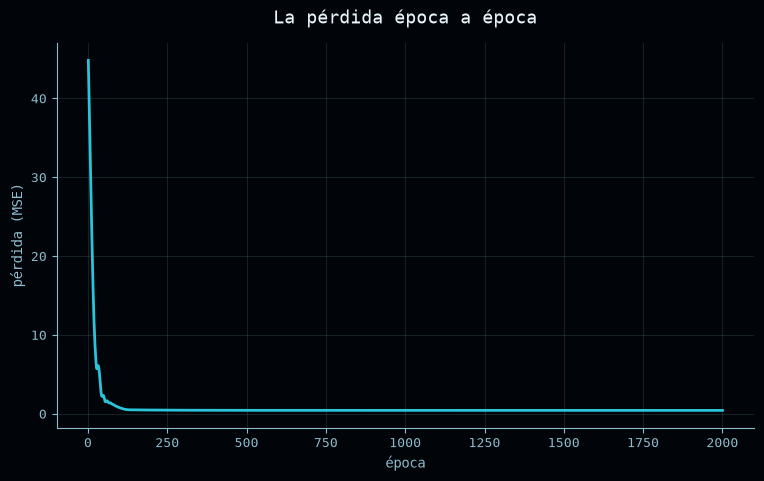

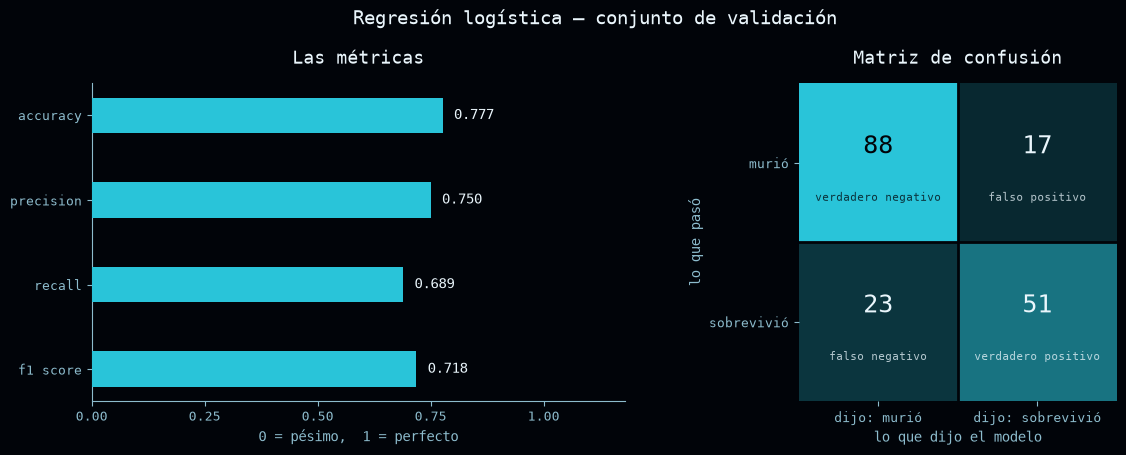

In [12]:
class RegresionLogistica(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)

    def forward(self, x):
        return self.linear(x)


modelo = RegresionLogistica(X_train.shape[1])
funcion_perdida = nn.BCEWithLogitsLoss()
optimizador = optim.Adam(modelo.parameters(), lr=0.01)

historial_log = []

for epoca in range(2000):
    optimizador.zero_grad()                            # 1. borrar los gradientes viejos
    predicciones = modelo(X_train)                     # 2. predecir
    perdida = funcion_perdida(predicciones, y_train)   # 3. medir el error
    perdida.backward()                                 # 4. calcular gradientes
    optimizador.step()                                 # 5. actualizar parametros

    historial_log.append(perdida.item())

    if (epoca + 1) % 200 == 0:
        print(f"Época {epoca + 1} — pérdida: {perdida}")

# Graficando la perdida
utils.dibujar_perdida(historial_log)

# Evaluando en el conjunto de validación
resultados = evaluar_metricas(modelo, val_loader)

utils.dibujar_resultados(resultados, titulo="Regresión logística — conjunto de validación")

----

<br>

## **Parte 5:** La red

La regresión logística es **una sola línea recta**. Toma las columnas, multiplica cada una por su peso, las suma y con ese número decide. Si la realidad no se deja partir con una línea, no hay peso que la salve.

Una red neuronal apila varias de esas líneas y mete una **activación** entre capa y capa. Eso es lo que le permite doblar la frontera: puede aprender que ser hombre pesa distinto en primera clase que en tercera, o que la edad importa solo hasta cierto punto.

Más capacidad, más libertad, muchos más parámetros. Debería ganar fácil.

**Vamos a ver.**

In [ ]:
class RedNeuronal(nn.Module):
    """Tres capas ocultas de 64 neuronas."""

    def __init__(self, n_features):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(n_features, 64),   # la parte lineal, igual que la regresión
            nn.ReLU(),                   # la que dobla
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1),            # un solo número de salida (el logit)
        )

    def forward(self, x):
        return self.red(x)


red = RedNeuronal(X_train.shape[1])

print(f"regresión logística: {sum(p.numel() for p in modelo.parameters()):>6,} parámetros")
print(f"red neuronal:        {sum(p.numel() for p in red.parameters()):>6,} parámetros")

La entrenamos con los mismos datos, la misma partición y la misma función de pérdida que la regresión. Lo único que cambia es el modelo.

Con un detalle nuevo: vamos a anotar la pérdida **en los dos conjuntos**, no solo en el de entrenamiento. Ya va a ver por qué importa.

In [ ]:
torch.manual_seed(42)

red = RedNeuronal(X_train.shape[1])
funcion_perdida = nn.BCEWithLogitsLoss()
optimizador = optim.Adam(red.parameters(), lr=0.001)

historial_red = {"entrenamiento": [], "validación": []}

for epoca in range(300):
    red.train()
    for X_lote, y_lote in train_loader:
        optimizador.zero_grad()                              # 1. borrar los gradientes viejos
        perdida = funcion_perdida(red(X_lote), y_lote)       # 2-3. predecir y medir el error
        perdida.backward()                                   # 4. calcular gradientes
        optimizador.step()                                   # 5. actualizar parámetros

    # Al final de cada época: ¿cómo va en cada conjunto?
    red.eval()
    with torch.no_grad():
        historial_red["entrenamiento"].append(funcion_perdida(red(X_train), y_train).item())
        historial_red["validación"].append(funcion_perdida(red(X_val), y_val).item())

utils.dibujar_metricas(
    historial_red,
    titulo="La red, época a época",
    y_etiqueta="pérdida (BCE)",
)

resultados_red = evaluar_metricas(red, val_loader)

utils.dibujar_resultados(resultados_red, titulo="Red neuronal — conjunto de validación")

### Ojo a esa gráfica

La línea de **entrenamiento** baja y baja, como debe ser: de 0.71 a 0.25.

La de **validación** baja un rato... y cerca de la **época 35** se devuelve para arriba, hasta terminar en 2.03 — mucho peor de donde arrancó.

Ese cruce es el momento exacto en que la red dejó de aprender el problema y empezó a **aprenderse los pasajeros de memoria**. Cada época que corre después de ahí la hace peor con gente que nunca ha visto, que es lo único que nos importa.

Si solo hubiéramos graficado la pérdida de entrenamiento —como hicimos con la regresión— habríamos jurado que todo iba de maravilla.

### Cara a cara

In [ ]:
utils.dibujar_comparacion(
    {
        "regresión logística": resultados,
        "red neuronal": resultados_red,
    },
    titulo="Conjunto de validación",
)


def accuracy_en(modelo_evaluado, X, y):
    modelo_evaluado.eval()
    with torch.no_grad():
        predichas = (torch.sigmoid(modelo_evaluado(X)) >= 0.5).float()
    return accuracy(y, predichas).item()


print(f"{'':<22}{'entrenamiento':>15}{'validación':>13}")
for nombre, m in [("regresión logística", modelo), ("red neuronal", red)]:
    print(f"{nombre:<22}{accuracy_en(m, X_train, y_train):>15.4f}"
          f"{accuracy_en(m, X_val, y_val):>13.4f}")

----

<br>

## **Parte 6:** Conclusión

La red tiene **9.089 parámetros**; la regresión logística tiene **11**.

Con esos parámetros de más, la red se aprendió los datos de entrenamiento mucho mejor —0.90 contra 0.80— y aun así **acierta menos donde importa**: 0.74 contra 0.78 en validación.

No es que esté mal programada. Es que el problema no da para más. El Titanic son ~700 filas donde *"mujer de primera clase sobrevive, hombre de tercera no"* explica casi todo, y eso una línea recta ya lo captura. La capacidad que sobra no se convierte en entendimiento: se convierte en memoria.

Las redes neuronales brillan cuando hay **muchísimos datos** y la relación entre la entrada y la salida es tan enredada que nadie la puede escribir a mano — imágenes, audio, texto. Ahí no hay regresión logística que compita, y de eso se trata el cuaderno que sigue.

<br>

> **La moraleja:** empiece por el modelo simple. Es el que le dice si el problema necesitaba una red. Si le gana la regresión logística, a la red no le faltaron capas: al problema no le hacía falta una red.

-----

<br>

### **Siguiente notebook:**

[`03_transfer_learning.ipynb`](03_transfer_learning.ipynb)

### <font color="#29c4d9">**Notebook 2 listo.**</font>

<br>

---

<div style="margin-top: 50px;"><center><a href="https://github.com/aperture-systems-lab"><img src="assets/banner_logo.png" width="955"/></a></center></div>